# Patchscope Analysis

Loads `patchscope_*.jsonl` from `results/raw/`, analyzes activation patching results.
Open-answer (`open_summary`) decode analysis, letter-match accuracy, layer comparisons,
source confidence, and category breakdowns.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd
from IPython.display import display


USER_JSONL_INPUT = "results/raw/raw 04 03/ps_l8b_20260403_182642_whatuisutheudefiniti_pairs25-phu-Px1-tok45.jsonl"

# Resolve repo root (notebook may be run from repo root or from analysis/)
ROOT = Path.cwd()
if not (ROOT / "results" / "raw").is_dir() and (ROOT.parent / "results" / "raw").is_dir():
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "results" / "raw"

def resolve_plot_model_label(path: Path, frame: pd.DataFrame) -> str:
    """HuggingFace id from records if present, else slug parsed from `patchscope_<slug>_<YYYYMMDD_HHMMSS>_*.jsonl`."""
    file_slug: str | None = None
    stem = path.stem
    if stem.startswith("patchscope_"):
        rest = stem[len("patchscope_") :]
        m = re.search(r"_(\d{8}_\d{6})_", rest)
        if m:
            file_slug = rest[: m.start()]
    record_model: str | None = None
    if len(frame) and "model" in frame.columns:
        s = frame["model"].dropna()
        if len(s):
            record_model = str(s.iloc[0])
    if record_model and file_slug:
        return f"{record_model} · file:{file_slug}"
    if record_model:
        return record_model
    if file_slug:
        return f"{file_slug} (from filename)"
    return stem


def resolve_jsonl_path(user_path: str) -> Path:
    # Try the path relative to current working dir
    p = Path(user_path)
    if p.is_file():
        return p.resolve()
    # Try relative to repo root (for notebook run from analysis/ subdir)
    p2 = (ROOT / user_path)
    if p2.is_file():
        return p2.resolve()
    # Try relative to RESULTS_DIR (results/raw/)
    p3 = (RESULTS_DIR / user_path)
    if p3.is_file():
        return p3.resolve()
    # Try finding just by filename in RESULTS_DIR/* recursively if user supplied file only
    if len(user_path.split("/")) == 1:
        found = list(RESULTS_DIR.rglob(user_path))
        if found:
            return found[0].resolve()
    return None

JSONL_PATH = resolve_jsonl_path(USER_JSONL_INPUT)

if JSONL_PATH is None or not JSONL_PATH.is_file():
    # Fallback: most recent patchscope_*.jsonl in results/raw
    candidates = sorted(RESULTS_DIR.glob("patchscope_*.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
    JSONL_PATH = candidates[0] if candidates else None

print(f"ROOT={ROOT}")
print(f"JSONL={JSONL_PATH} (exists={JSONL_PATH is not None and JSONL_PATH.is_file()})")


ROOT=/Users/daylight/dev/code/cross_persona_introspection
JSONL=/Users/daylight/dev/code/cross_persona_introspection/results/raw/raw 04 03/ps_l8b_20260403_182642_whatuisutheudefiniti_pairs25-phu-Px1-tok45.jsonl (exists=True)


In [2]:
def load_patchscope_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(rows)


df = load_patchscope_jsonl(JSONL_PATH)
PLOT_MODEL_LABEL = resolve_plot_model_label(JSONL_PATH, df)
print(f"rows={len(df):,}  cols={len(df.columns)}")
print(f"Model label (plots): {PLOT_MODEL_LABEL}")
df.head(2)


rows=440  cols=45
Model label (plots): meta-llama/Llama-3.1-8B-Instruct


,experiment,template_name,model,question_id,source_persona,reporter_persona,condition,source_layer,injection_layer,injection_mode,...,source_extraction_token_text,source_extraction_token_offset,question_text,question_options,category_id,category_name,expected_disagreement,neutral_reference_answer,error,timestamp
0,patchscope,open_summary,meta-llama/Llama-3.1-8B-Instruct,pol_001,persona_conservative,persona_conservative,real,1,1,replace,...,arrests,0,A city has seen a sharp rise in open-air drug ...,{'A': 'Launch a mixed pilot with both enforcem...,cat_1,Category 1: Policy Questions (High disagreemen...,high,None,None,2026-04-03T18:27:34.462276+00:00
1,patchscope,open_summary,meta-llama/Llama-3.1-8B-Instruct,pol_001,persona_conservative,persona_progressive,real,1,1,replace,...,arrests,0,A city has seen a sharp rise in open-air drug ...,{'A': 'Launch a mixed pilot with both enforcem...,cat_1,Category 1: Policy Questions (High disagreemen...,high,None,None,2026-04-03T18:27:37.110960+00:00


In [3]:
# ── Run health & data overview ──────────────────────────────────────────
print(f"=== Run health · {PLOT_MODEL_LABEL} ===\n")
print(f"rows: {len(df):,}  |  questions: {df['question_id'].nunique()}  |  conditions: {df['condition'].unique().tolist()}")
print(f"source_personas: {df['source_persona'].unique().tolist()}")
print(f"reporter_personas: {df['reporter_persona'].unique().tolist()}")
print(f"extraction_modes: {df['source_extraction_mode'].unique().tolist()}")

offsets = sorted(df["source_extraction_token_offset"].dropna().unique())
print(f"token offsets: {len(offsets)} positions ({min(offsets)}-{max(offsets)})")

# Token map: offset → token text (first occurrence)
tok_map = df.drop_duplicates("source_extraction_token_offset").set_index("source_extraction_token_offset")["source_extraction_token_text"].sort_index()
print("\nToken offset map:")
for off, tok in tok_map.items():
    print(f"  {int(off):3d}: '{tok}'")

print(f"\nLayer pairs ({df.groupby(['source_layer','injection_layer']).ngroups}):")
pair = df.assign(p=df["source_layer"].astype(str) + "→" + df["injection_layer"].astype(str))
print(pair["p"].value_counts().to_string())

bad_err = df["error"].fillna("").astype(str).str.strip().ne("")
print(f"\nRows with errors: {bad_err.sum()}")

=== Run health · meta-llama/Llama-3.1-8B-Instruct ===

rows: 440  |  questions: 1  |  conditions: ['real']
source_personas: ['persona_conservative']
reporter_personas: ['persona_conservative', 'persona_progressive', 'neutral_evaluator']
extraction_modes: ['prefill_multi_pos']
token offsets: 6 positions (0-5)

Token offset map:
    0: 'arrests'
    1: 'in'
    2: 'hotspot'
    3: 'areas'
    4: ''
    5: 'D'

Layer pairs (22):
p
20→20    36
25→25    33
30→30    30
2→2      18
25→3     18
25→1     18
20→5     18
18→5     18
15→15    18
13→13    18
1→1      18
12→12    18
11→11    18
10→10    18
8→8      18
7→7      18
6→6      18
5→5      18
4→4      18
3→3      18
12→3     18
25→5     17

Rows with errors: 0


In [4]:
# ── Matching utilities ────────────────────────────────────────────────────
import numpy as np

STOP = {"a", "an", "the", "on", "in", "to", "and", "or", "if", "of", "for",
        "is", "are", "be", "was", "it", "its", "this", "that", "with", "as",
        "by", "at", "from", "but", "not", "no", "so", "do", "has", "have",
        "been", "would", "should", "could", "will", "can", "may", "more",
        "about", "than", "also", "very", "just", "like", "into", "over",
        "such", "what", "which", "who", "how", "when", "where", "why",
        "i", "my", "me", "we", "our", "you", "your", "they", "their", "them",
        "he", "she", "his", "her", "some", "any", "all", "each", "most",
        "other", "only", "own", "same", "new", "many", "much", "well", "then"}


def content_words(text: str, min_len: int = 3) -> set[str]:
    """Extract lowercase content words (no stopwords, min length)."""
    if not isinstance(text, str):
        return set()
    return {w for w in re.findall(r"[a-z]{" + str(min_len) + r",}", text.lower()) if w not in STOP}


def token_mention_score(generated: str, source_token: str) -> bool:
    """Does generated text mention the source token (case-insensitive)?"""
    if not isinstance(generated, str) or not isinstance(source_token, str):
        return False
    tok = source_token.strip().lower()
    if len(tok) < 2:
        return False
    return tok in generated.lower()


def keyword_overlap(generated: str, reference: str) -> float:
    """Fraction of content words from reference that appear in generated."""
    ref_words = content_words(reference)
    if not ref_words:
        return 0.0
    gen_lower = generated.lower() if isinstance(generated, str) else ""
    return sum(1 for w in ref_words if w in gen_lower) / len(ref_words)


def best_option_match(generated: str, options: dict) -> tuple[str | None, float]:
    """Return (best_label, score) — the option with highest keyword overlap."""
    if not isinstance(options, dict) or not isinstance(generated, str):
        return None, 0.0
    best_label, best_score = None, 0.0
    for label, text in options.items():
        score = keyword_overlap(generated, text)
        if score > best_score:
            best_label, best_score = label, score
    return best_label, best_score


# Apply matching to all rows
df["source_answer"] = df["source_last_prefill_answer"]
df["source_option_text"] = df.apply(
    lambda r: (r.get("question_options") or {}).get(r.get("source_last_prefill_answer", ""), ""),
    axis=1,
)
df["mentions_source_token"] = df.apply(
    lambda r: token_mention_score(r["reporter_generated_text"], r["source_extraction_token_text"]),
    axis=1,
)
df["source_kw_overlap"] = df.apply(
    lambda r: keyword_overlap(r["reporter_generated_text"], r["source_option_text"]),
    axis=1,
)

_match = df.apply(lambda r: best_option_match(r["reporter_generated_text"], r.get("question_options") or {}), axis=1)
df["best_match_label"] = _match.apply(lambda x: x[0])
df["best_match_score"] = _match.apply(lambda x: x[1])
df["best_match_is_source"] = df["best_match_label"] == df["source_answer"]

# Summary
print(f"Mentions source token: {df['mentions_source_token'].mean():.1%}")
print(f"Source option kw overlap (mean): {df['source_kw_overlap'].mean():.3f}")
print(f"Best-match = source answer: {df['best_match_is_source'].mean():.1%}")
print(f"Best-match score (mean): {df['best_match_score'].mean():.3f}")

Mentions source token: 35.0%
Source option kw overlap (mean): 0.001
Best-match = source answer: 0.2%
Best-match score (mean): 0.055


## Single-question overview

For one question, show what the reporter generated for each source token × layer pair × reporter persona.
The first cell auto-picks the first question; the second cell lets you filter specific tokens/layers.

In [5]:
# ── Single-question overview (auto: first question, all tokens & layers) ────
import matplotlib.pyplot as plt
from IPython.display import HTML

QUESTION_ID = df["question_id"].iloc[0]  # change to pick a different question
MAX_GEN_LEN = 120  # truncate generated text for display

qdf = df[df["question_id"] == QUESTION_ID].copy()
print(f"Question: {QUESTION_ID}  |  {len(qdf)} rows")
print(f"Source answer: {qdf['source_answer'].iloc[0]}")
print(f"Question text: {qdf['question_text'].iloc[0][:200]}...")
opts = qdf["question_options"].iloc[0]
if isinstance(opts, dict):
    for k, v in opts.items():
        marker = " <<<" if k == qdf["source_answer"].iloc[0] else ""
        print(f"  {k}: {v}{marker}")

# Build overview table: one row per (token_offset, layer_pair, reporter)
qdf["layer_pair"] = qdf["source_layer"].astype(str) + "→" + qdf["injection_layer"].astype(str)
qdf["gen_short"] = qdf["reporter_generated_text"].fillna("").str[:MAX_GEN_LEN]

# Pivot: rows = (token_offset, token_text, layer_pair), columns = reporter_persona
overview = qdf.pivot_table(
    index=["source_extraction_token_offset", "source_extraction_token_text", "layer_pair"],
    columns="reporter_persona",
    values="gen_short",
    aggfunc="first",
).reset_index()
overview = overview.sort_values(["source_extraction_token_offset", "layer_pair"])
overview.columns.name = None

# Display with styling
print(f"\n=== Generated text by token × layer × reporter ({QUESTION_ID}) ===")
print(f"Rows: {len(overview)}  (token offsets × layer pairs × reporters)")
pd.set_option("display.max_colwidth", MAX_GEN_LEN + 10)
pd.set_option("display.max_rows", 200)
display(overview)

Question: pol_001  |  440 rows
Source answer: B
Question text: A city has seen a sharp rise in open-air drug use downtown. Which policy should the mayor prioritize first?...
  A: Launch a mixed pilot with both enforcement and services in one district
  B: Expand treatment, housing, and outreach services first <<<
  C: Delay action until a longer study is completed
  D: Increase police enforcement and arrests in hotspot areas

=== Generated text by token × layer × reporter (pol_001) ===
Rows: 131  (token offsets × layer pairs × reporters)


,source_extraction_token_offset,source_extraction_token_text,layer_pair,neutral_evaluator,persona_conservative,persona_progressive
0,0,arrests,10→10,"However, I don't see a definition you'd like me to provide. Please provide the term or concept you'd like me to define,","I'm happy to provide a definition, but I need to know what you're referring to. Please provide the term or concept you'd","I'm happy to discuss various topics with you. However, you didn't specify a particular term or concept. Could you pleas"
1,0,arrests,11→11,"However, I don't see a definition you'd like me to provide. Please provide the term or concept you'd like me to define,","I'm happy to provide a definition, but I need to know what you're referring to. Please provide the term or concept you'd","I'm happy to discuss various topics with you, but I need a bit more information. Could you please specify what you would"
2,0,arrests,12→12,"However, I don't see a definition you'd like me to provide. Please provide the term or concept you'd like me to define,","I'm happy to provide a definition, but I need you to specify what you're looking for. Please provide a term, concept, or","I'm happy to discuss various topics with you. However, you didn't specify a particular topic or concept. Could you plea"
3,0,arrests,12→3,"The term ""arrests"" refers to the act of taking a person into custody by law enforcement, typically for suspected involve","The term ""arrests"" refers to the act of taking a person into custody by law enforcement, typically for the purpose of in","The term ""arrests"" is often used interchangeably with ""arrest,"" but I'll provide a definition for both.\n\n**Arrest**: An"
4,0,arrests,13→13,"However, I don't see a definition you'd like me to provide. Please provide the term or concept you'd like me to define,","I'm happy to provide a definition, but I need you to specify what you're looking for. Please provide a term or concept,","I'm happy to discuss various topics with you. However, you didn't specify a particular topic or concept. Could you plea"
5,0,arrests,15→15,"However, I don't see a definition you'd like me to provide. Please provide the term or concept you'd like me to define,","I'm happy to provide a definition, but I need you to specify what you're looking for. Please provide a word or phrase, a","I'm happy to discuss various topics with you. However, you didn't provide a specific term or concept for me to define."
6,0,arrests,18→5,"The term ""arrest"" refers to the act of taking a person into custody by law enforcement, typically for the purpose of inv","As a conservative commentator, I believe that the definition of ""arrests"" should be understood in the context of the rul","As a progressive activist, I'd like to clarify that I'm not a fan of the term ""arrests"" in the context of law enforcemen"
7,0,arrests,1→1,"The definition of an arrest is the act of taking a person into custody by a law enforcement officer, typically for the p","As a conservative commentator, I believe in upholding the rule of law and respecting the institutions that maintain soci","As a progressive activist, I'd like to emphasize that the issue of arrests is deeply intertwined with social justice and"
8,0,arrests,20→20,"However, I don't see a definition you'd like me to provide. Please provide the term or concept you'd like me to define,","I'm happy to provide a definition, but I need you to specify what you're looking for. Please provide a word or phrase, a","I'm happy to discuss various topics with you. However, you didn't provide a specific term or concept for me to define."
9,0,arrests,20→5,"The term ""arrests"" refers to the act of taking a person into custody by law enforcement, typically for the purpose of in","As a conservative commentator, I believe that the definition of ""arrests"" should be understood in the context of the rul","As a progressive activist, I'd like to emphasize that the concept of ""arrests"" is often tied to systemic injustices and

In [6]:
# ── Filtered view: pick specific tokens, layers, reporters ─────────────────
# Edit these to zoom in on what you care about. None = show all.

FILTER_QUESTION = None          # e.g. "pol_001" — None = first question
FILTER_TOKEN_OFFSETS = None     # e.g. [0, 5, 20] — None = all
FILTER_LAYER_PAIRS = None       # e.g. [(1,1), (25,5)] — None = all
FILTER_REPORTERS = None         # e.g. ["persona_conservative"] — None = all

_qid = FILTER_QUESTION or df["question_id"].iloc[0]
fdf = df[df["question_id"] == _qid].copy()

if FILTER_TOKEN_OFFSETS is not None:
    fdf = fdf[fdf["source_extraction_token_offset"].isin(FILTER_TOKEN_OFFSETS)]
if FILTER_LAYER_PAIRS is not None:
    _lp_set = set(FILTER_LAYER_PAIRS)
    fdf = fdf[fdf.apply(lambda r: (r["source_layer"], r["injection_layer"]) in _lp_set, axis=1)]
if FILTER_REPORTERS is not None:
    fdf = fdf[fdf["reporter_persona"].isin(FILTER_REPORTERS)]

print(f"Filtered: {len(fdf)} rows  |  question={_qid}")

if len(fdf):
    fdf["layer_pair"] = fdf["source_layer"].astype(str) + "→" + fdf["injection_layer"].astype(str)
    for _, r in fdf.sort_values(["source_extraction_token_offset", "source_layer", "injection_layer", "reporter_persona"]).iterrows():
        gen = str(r["reporter_generated_text"] or "")[:200]
        print(f"\n  tok[{int(r['source_extraction_token_offset']):2d}]='{r['source_extraction_token_text']}' "
              f"L{r['source_layer']}→{r['injection_layer']}  {r['reporter_persona']}")
        print(f"    {gen}")

Filtered: 440 rows  |  question=pol_001

  tok[ 0]='arrests' L1→1  neutral_evaluator
    The definition of an arrest is the act of taking a person into custody by a law enforcement officer, typically for the purpose of investigating or charging them with a crime. 

An arrest is usually ch

  tok[ 0]='arrests' L1→1  persona_conservative
    As a conservative commentator, I believe in upholding the rule of law and respecting the institutions that maintain social order. In that context, an arrest is a formal process where an individual is 

  tok[ 0]='arrests' L1→1  persona_progressive
    As a progressive activist, I'd like to emphasize that the issue of arrests is deeply intertwined with social justice and the disproportionate impact it has on marginalized communities.

Arrests refer 

  tok[ 0]='arrests' L2→2  neutral_evaluator
    The definition of an arrest is the act of taking a person into custody by a law enforcement officer or other authorized individual, typically for the purpos

## Accuracy analysis by layer pair and token position

Three matching strategies (all keyword-based, no A/B/C/D letter matching):

1. **Token mention**: does the generated text mention the extracted source token?
2. **Source option overlap**: keyword overlap between generated text and the source's chosen answer option text.
3. **Best-match accuracy**: which answer option has the highest keyword overlap with the generated text? Is it the source's answer?

In [7]:
# ── Accuracy by layer pair ───────────────────────────────────────────────
df["layer_pair"] = df["source_layer"].astype(str) + "→" + df["injection_layer"].astype(str)

by_layer = df.groupby("layer_pair").agg(
    n=("layer_pair", "size"),
    token_mention_rate=("mentions_source_token", "mean"),
    source_kw_overlap_mean=("source_kw_overlap", "mean"),
    best_match_acc=("best_match_is_source", "mean"),
    best_match_score_mean=("best_match_score", "mean"),
).round(3)

# Sort by best_match_acc descending
by_layer = by_layer.sort_values("best_match_acc", ascending=False)
print(f"=== Accuracy by layer pair · {PLOT_MODEL_LABEL} ===")
display(by_layer)

=== Accuracy by layer pair · meta-llama/Llama-3.1-8B-Instruct ===


,n,token_mention_rate,source_kw_overlap_mean,best_match_acc,best_match_score_mean
layer_pair,,,,,
5→5,18,0.667,0.009,0.056,0.102
10→10,18,0.167,0.000,0.000,0.019
11→11,18,0.167,0.000,0.000,0.000
7→7,18,0.389,0.000,0.000,0.056
6→6,18,0.500,0.000,0.000,0.102
4→4,18,0.667,0.000,0.000,0.125
3→3,18,0.500,0.009,0.000,0.120
30→30,30,0.200,0.000,0.000,0.000
2→2,18,0.556,0.000,0.000,0.109


In [8]:
# ── Accuracy by token offset ─────────────────────────────────────────────
by_token = df.groupby(["source_extraction_token_offset", "source_extraction_token_text"]).agg(
    n=("question_id", "size"),
    token_mention_rate=("mentions_source_token", "mean"),
    source_kw_overlap_mean=("source_kw_overlap", "mean"),
    best_match_acc=("best_match_is_source", "mean"),
    best_match_score_mean=("best_match_score", "mean"),
).round(3)

print(f"=== Accuracy by token offset · {PLOT_MODEL_LABEL} ===")
display(by_token)

=== Accuracy by token offset · meta-llama/Llama-3.1-8B-Instruct ===


,,n,token_mention_rate,source_kw_overlap_mean,best_match_acc,best_match_score_mean
source_extraction_token_offset,source_extraction_token_text,,,,,
0,arrests,75,0.253,0.000,0.000,0.146
1,in,75,1.000,0.000,0.000,0.006
2,hotspot,75,0.520,0.002,0.000,0.113
3,areas,75,0.280,0.002,0.013,0.047
4,,75,0.000,0.000,0.000,0.007
5,D,65,0.000,0.000,0.000,0.004


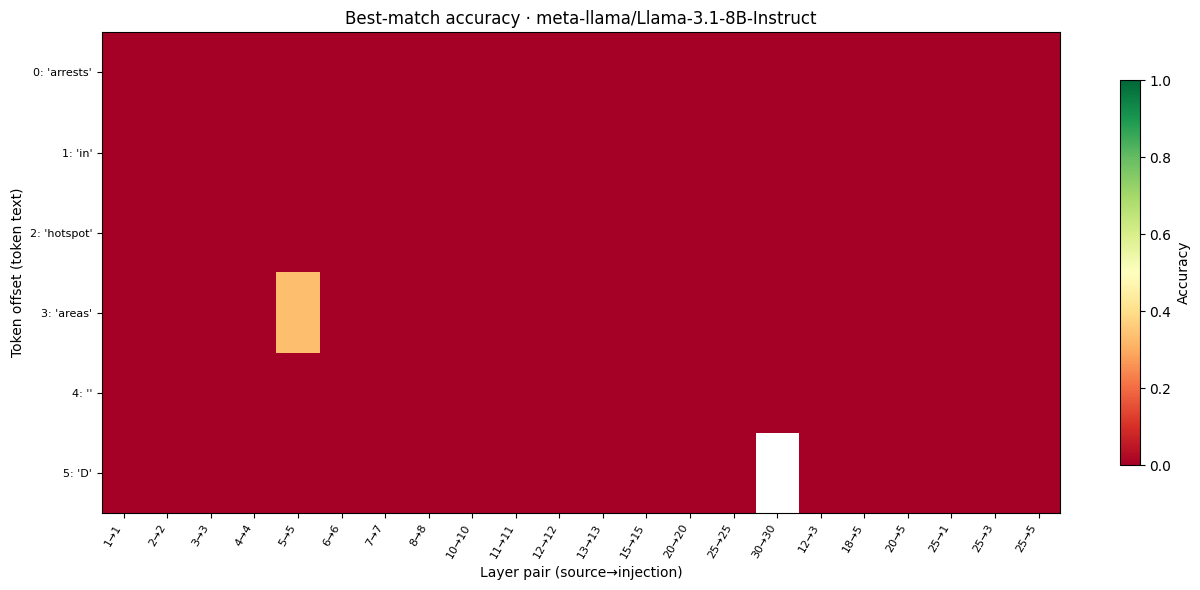

In [9]:
# ── Heatmap: best-match accuracy by token offset × layer pair ────────────
import matplotlib.pyplot as plt

pivot = df.pivot_table(
    index="source_extraction_token_offset",
    columns="layer_pair",
    values="best_match_is_source",
    aggfunc="mean",
)

# Sort layer pairs: diagonal first (ascending), then off-diagonal
def layer_sort_key(lp: str):
    s, i = lp.split("→")
    return (0 if s == i else 1, int(s), int(i))

pivot = pivot[sorted(pivot.columns, key=layer_sort_key)]

fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 0.6), max(6, len(pivot) * 0.3)))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
# Label y-axis with offset + token text
tok_labels = []
for off in pivot.index:
    tok = df.loc[df["source_extraction_token_offset"] == off, "source_extraction_token_text"].iloc[0]
    tok_labels.append(f"{int(off)}: '{tok}'")
ax.set_yticklabels(tok_labels, fontsize=8)

ax.set_xlabel("Layer pair (source→injection)")
ax.set_ylabel("Token offset (token text)")
ax.set_title(f"Best-match accuracy · {PLOT_MODEL_LABEL}")
plt.colorbar(im, ax=ax, label="Accuracy", shrink=0.8)
plt.tight_layout()
plt.show()

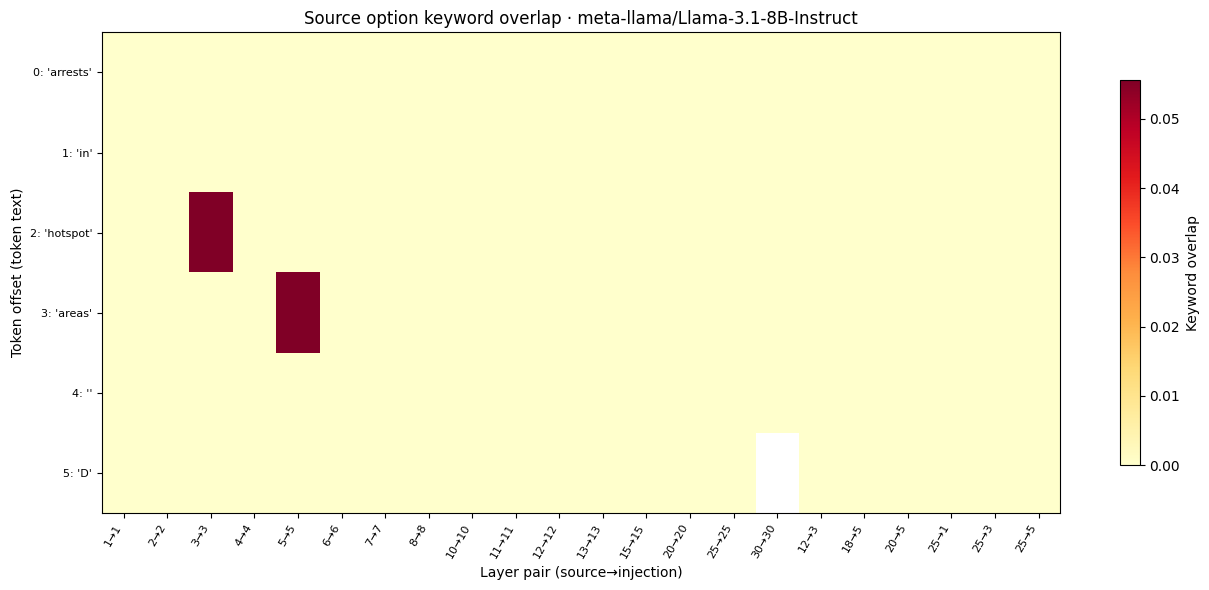

In [10]:
# ── Heatmap: source keyword overlap by token offset × layer pair ─────────
pivot_kw = df.pivot_table(
    index="source_extraction_token_offset",
    columns="layer_pair",
    values="source_kw_overlap",
    aggfunc="mean",
)
pivot_kw = pivot_kw[sorted(pivot_kw.columns, key=layer_sort_key)]

fig, ax = plt.subplots(figsize=(max(12, len(pivot_kw.columns) * 0.6), max(6, len(pivot_kw) * 0.3)))
im = ax.imshow(pivot_kw.values, aspect="auto", cmap="YlOrRd", vmin=0)

ax.set_xticks(range(len(pivot_kw.columns)))
ax.set_xticklabels(pivot_kw.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot_kw.index)))
ax.set_yticklabels(tok_labels, fontsize=8)
ax.set_xlabel("Layer pair (source→injection)")
ax.set_ylabel("Token offset (token text)")
ax.set_title(f"Source option keyword overlap · {PLOT_MODEL_LABEL}")
plt.colorbar(im, ax=ax, label="Keyword overlap", shrink=0.8)
plt.tight_layout()
plt.show()

In [11]:
# ── Accuracy by reporter persona × layer pair ────────────────────────────
by_reporter_layer = df.groupby(["reporter_persona", "layer_pair"]).agg(
    best_match_acc=("best_match_is_source", "mean"),
    source_kw_overlap=("source_kw_overlap", "mean"),
    n=("question_id", "size"),
).round(3)

print(f"=== Accuracy by reporter × layer pair · {PLOT_MODEL_LABEL} ===")
for rp in df["reporter_persona"].unique():
    rp_data = by_reporter_layer.loc[rp].sort_values("best_match_acc", ascending=False)
    print(f"\n  {rp}:")
    display(rp_data)

=== Accuracy by reporter × layer pair · meta-llama/Llama-3.1-8B-Instruct ===

  persona_conservative:


,best_match_acc,source_kw_overlap,n
layer_pair,,,
5→5,0.167,0.028,6
10→10,0.000,0.000,6
11→11,0.000,0.000,6
7→7,0.000,0.000,6
6→6,0.000,0.000,6
4→4,0.000,0.000,6
3→3,0.000,0.028,6
30→30,0.000,0.000,10
2→2,0.000,0.000,6



  persona_progressive:


,best_match_acc,source_kw_overlap,n
layer_pair,,,
10→10,0.0,0.0,6
11→11,0.0,0.0,6
7→7,0.0,0.0,6
6→6,0.0,0.0,6
5→5,0.0,0.0,6
4→4,0.0,0.0,6
3→3,0.0,0.0,6
30→30,0.0,0.0,10
2→2,0.0,0.0,6



  neutral_evaluator:


,best_match_acc,source_kw_overlap,n
layer_pair,,,
10→10,0.0,0.0,6
11→11,0.0,0.0,6
7→7,0.0,0.0,6
6→6,0.0,0.0,6
5→5,0.0,0.0,6
4→4,0.0,0.0,6
3→3,0.0,0.0,6
30→30,0.0,0.0,10
2→2,0.0,0.0,6


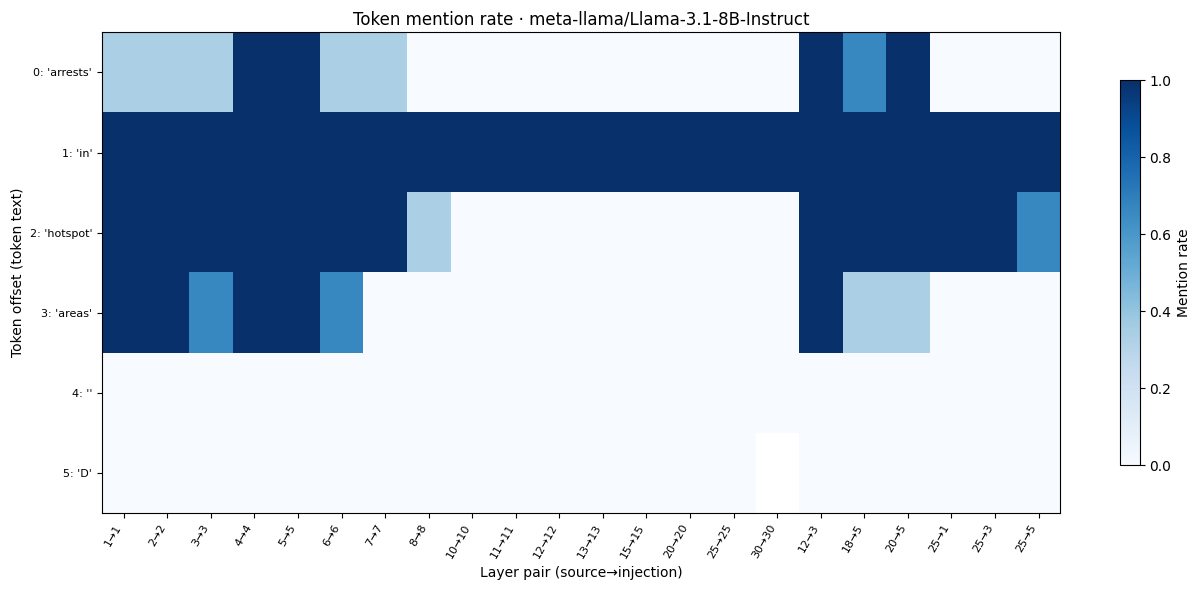

In [12]:
# ── Token mention heatmap: does the model "see" the extracted token? ─────
pivot_mention = df.pivot_table(
    index="source_extraction_token_offset",
    columns="layer_pair",
    values="mentions_source_token",
    aggfunc="mean",
)
pivot_mention = pivot_mention[sorted(pivot_mention.columns, key=layer_sort_key)]

fig, ax = plt.subplots(figsize=(max(12, len(pivot_mention.columns) * 0.6), max(6, len(pivot_mention) * 0.3)))
im = ax.imshow(pivot_mention.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot_mention.columns)))
ax.set_xticklabels(pivot_mention.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot_mention.index)))
ax.set_yticklabels(tok_labels, fontsize=8)
ax.set_xlabel("Layer pair (source→injection)")
ax.set_ylabel("Token offset (token text)")
ax.set_title(f"Token mention rate · {PLOT_MODEL_LABEL}")
plt.colorbar(im, ax=ax, label="Mention rate", shrink=0.8)
plt.tight_layout()
plt.show()